# Import Rideshare Data

In [2]:
import numpy as np
import pandas as pd
import matplotlib

Uncomment this cell to run (1-5 min):

Reccomend that you have 16gb storage on your computer to run this

In [ ]:
# df = pd.read_csv("<path_to_your_rideshare_data_file>.csv")

/var/folders/85/f68ppp2j4cg5ykw_cvg3t4gw0000gn/T/ipykernel_20422/1247983384.py:1: DtypeWarning: Columns (0: Trip Miles) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("~/Downloads/tnp.csv")


Select only the cells we want and store as `share`: 

In [10]:
master_share = df[['Trip ID', 'Trip Start Timestamp', 'Trip End Timestamp', 'Trip Seconds', 'Trip Miles', 'Percent Time Chicago', 'Percent Distance Chicago', 'Pickup Census Tract', 'Dropoff Census Tract', 'Fare', 'Tip', 'Additional Charges','Trip Total', 'Pickup Centroid Latitude', 'Pickup Centroid Longitude','Dropoff Centroid Latitude','Dropoff Centroid Longitude']]

share = master_share

In [11]:
# Should have 31146361 rows
len(share)

93510249

First on the cleaning agenda:
    There are some percentage (time and distance) that are greater than 100.
    Let's see how many of those there are and decide what to do about those.

2 options:
    a) delete them
    b) Check if lat and long start and end are both in chicago, if so keep, else delete

Convert percntages into a usable datatype, int (20-30s):
(For this conversion to work, first we need to remove rows with missing values if this hasn't already been done - this cell took 3 minutes in total to run with a longer start csv.)

In [13]:
share = share.dropna(subset=["Percent Time Chicago", "Percent Distance Chicago"])

share['Int Percent Time Chicago'] = (
    share['Percent Time Chicago'].str.replace("%", "").str.replace(",", "")
).astype(int)

share['Int Percent Distance Chicago'] = (
    share['Percent Distance Chicago'].str.replace("%", "").str.replace(",", "")
).astype(int)

In [15]:
time_over = (share['Int Percent Time Chicago'] > 100).sum()
time_in = (share['Int Percent Time Chicago'] == 100).sum()

dist_over = (share['Int Percent Distance Chicago'] > 100).sum()
dist_in = (share['Int Percent Distance Chicago'] == 100).sum()

print(f"{time_over} rows have a percentage of time over 100%, compared to {time_in} that are normal\nso unrealistic percentages make up {round(time_over  * 100 / (time_over + time_in), 3)}% of the dataset")

print(f"{dist_over} rows have a percentage of distance over 100%, compared to {dist_in} that are normal\nso unrealistic percentages make up {round(dist_over  * 100 / (dist_over + dist_in), 3)}% of the dataset")

26212 rows have a percentage of time over 100%, compared to 71546087 that are normal
so unrealistic percentages make up 0.037% of the dataset
22598 rows have a percentage of distance over 100%, compared to 60202904 that are normal
so unrealistic percentages make up 0.038% of the dataset


Because the percentage of the data that has unrealistic time or duration percentages is relativley low, for simplicity's sake we're just going to remove those rows from the dataset for this round of exploration.

In [16]:
before_len = len(share)
print(f"Before removing rows with unlikely time/distance percentages, we have {before_len} rows in the dataset")

#  Save a copy of the data before removing rows, in case we want to come back to it
share_with_perc = share

Before removing rows with unlikely time/distance percentages, we have 93106410 rows in the dataset


(15-20s if csv is filtered on percent time and percent distance, 4.5 mins if not)

In [17]:
share = share[share['Int Percent Time Chicago'] == 100]
share = share[share['Int Percent Distance Chicago'] == 100]

after_len = len(share)
print(f"We are left with {after_len} rows in the dataset, having removed {before_len - after_len}")

We are left with 57725849 rows in the dataset, having removed 35380561


Remove percentage time and percentage distance cols as that's no longer relevant.  Let's take a look at the data.

In [18]:
share = share[['Trip ID', 'Trip Start Timestamp', 'Trip End Timestamp', 'Trip Seconds', 'Trip Miles', 'Pickup Census Tract', 'Dropoff Census Tract', 'Fare', 'Tip', 'Additional Charges','Trip Total', 'Pickup Centroid Latitude', 'Pickup Centroid Longitude','Dropoff Centroid Latitude','Dropoff Centroid Longitude']]
share_before_nan_drop = share

Replace string "NaN" to true null `np.nan` (10-40)

In [19]:
share = share.replace('NaN', np.nan)

Dropping all NAs took about 2 minutes.

In [20]:
share = share.dropna()

Next, we ensure that all trips in the dataframe start and end within calendar year 2025. This took ~3 minutes for a long version of the start data.

In [25]:
share = share[share['Trip Start Timestamp'] >= "01/01/2025 12:00:00 AM"]
share = share[share['Trip End Timestamp'] <= "12/31/2025 11:59:59 PM"]
              

In [ ]:
clean_share = share
print(f"After basic cleaning, we are left with {len(share)} rows")

# Sabrina: 19264104
# Molly: 38002687

After basic cleaning, we are left with 38002687 rows


## Paring Down

At this point I would consider the  most basic level of cleaning done.  Next we do exploration and figure out how to dramatically par down our data while still preserving the nature of the data

Potential paths:

- Acccording to google, 2-3 decimal places is 1.1km to 111m precision. We definitley do not want to be more granular than 3 decimals, but curious to see how much dropping from 3 to 2 decimal places reduces the start/stop pairs we need to make api calls for.
- How much census tract data is missing? (JK after the NaN cleaning step we should only have complete data)
- How much data is in 1 week? 1 month?
- Should we randomly select 100,000 rows ??

### Clustering by coarse lat/long

How many unique start and end lat/long pairs exist if we truncate to 3 decimal points? 

In [ ]:
clustered = clean_share

clustered["Pickup Centroid Latitude"] = clustered["Pickup Centroid Latitude"].round(3)
clustered["Pickup Centroid Longitude"] = clustered["Pickup Centroid Longitude"].round(3)
clustered["Dropoff Centroid Latitude"] = clustered["Dropoff Centroid Latitude"].round(3)
clustered["Dropoff Centroid Longitude"] = clustered["Dropoff Centroid Longitude"].round(3)

unique_combos = clustered[["Pickup Centroid Latitude", "Pickup Centroid Longitude", "Dropoff Centroid Latitude", "Dropoff Centroid Longitude"]].drop_duplicates()
print(f"After rounding to 3 decimal points (~111m), we are left with {len(unique_combos)} unique pickup-dropoff pairs.")

After rounding to 3 decimal points (~111m), we are left with 397329 unique pickup-dropoff pairs


If we truncate to 3 decimal points and just look at one week of data?

### Removing unnecessarily expensive rides

Total trip cost to float

In [28]:
share['Int Total'] = (
    share['Trip Total'].str.replace("$", "").str.replace(",", "")
).astype(float)

Can we exclude extremely expensive rides?

In [29]:
share.sort_values(by = 'Int Total', ascending=False).head()

KeyboardInterrupt: 

np.int64(7796)

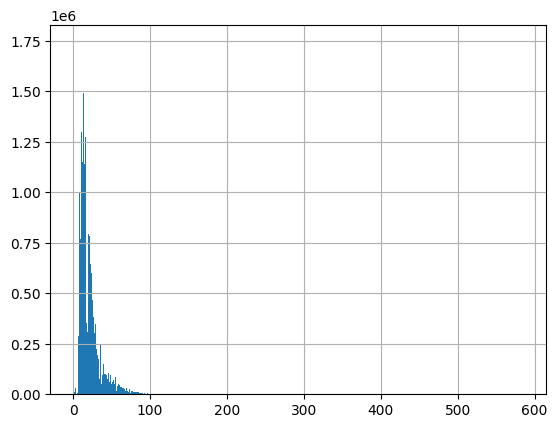

In [ ]:
share['Int Total'].hist(bins = 500)

Number of rides that are over $100:

In [76]:
(share['Int Total'] > 100).sum()

np.int64(62351)